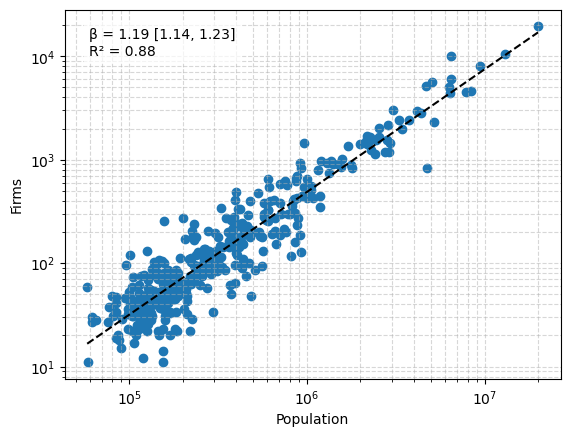

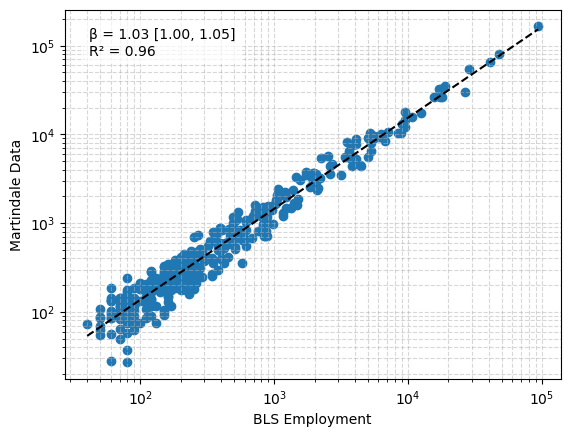

In [5]:
import pandas as pd
import geopandas as gpd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import sys
from pathlib import Path

current_path = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [current_path, *current_path.parents] if (p / "Scripts").is_dir()), None)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from within the repository.")

scripts_directory = PROJECT_ROOT / "Scripts" / "Helpers"

if str(scripts_directory) not in sys.path:
    sys.path.append(str(scripts_directory))

from Helpers import *

# Load data
# FIPS
fips_path = PROJECT_ROOT/"Data/Geography/FIPS/US states FIPS.csv"   # FIPS path
df_fips = pd.read_csv(fips_path)  # Load FIPS
df_fips["FIPS Code"] = df_fips["FIPS Code"].astype(str).str.zfill(2)    # Ensure string, add 0 to single digits

# MSAs
msa_shapefile_path = PROJECT_ROOT/"Data/Geography/CBSA_shapefile_2025/tl_2025_us_cbsa.shp"    # Shapefile path
gdf_msa = gpd.read_file(msa_shapefile_path) # Load MSA shapefile

gdf_msa = gdf_msa[gdf_msa["LSAD"] == 'M1'].reset_index(drop=True)   # Remove micro
gdf_msa['State_Abbr'] = gdf_msa['NAME'].str[-2:]    # Get state abbriviations
gdf_msa = gdf_msa[gdf_msa['State_Abbr'].isin(df_fips['Postal Abbr.'])].copy()   # Filter only US states
valid_geoid = gdf_msa["GEOID"].astype(str).tolist()  # GEOID list

# Population
pop_path = PROJECT_ROOT/"Data/Population Data/MSA Population/ACSDT1Y2024.B01003-Data.csv" # Population data Path
population_data = pd.read_csv(pop_path)   # Load data

population_data = population_data[['GEO_ID', 'NAME', 'B01003_001E']].copy()  # Take relevant columns
population_data.rename(columns={'GEO_ID': 'AREA', 'NAME': 'MSA', 'B01003_001E': 'Population'}, inplace=True) # Rename columns

population_data = population_data.iloc[1:].reset_index(drop=True) # Remove first row

population_data['AREA'] = population_data['AREA'].str[-5:]    # Get GEOID
population_data["AREA"] = population_data["AREA"].astype(str) # GEOID as string

population_data = population_data[population_data["AREA"].isin(valid_geoid)]   # Take only MSAs from the list

# BLS data
bls_path = PROJECT_ROOT/"Data/Processed Data/Filtered Tables/MSA_2024_Filtered_Extended_Professions.xlsx" # BLS data Path
bls_data = pd.read_excel(bls_path)   # Load data

bls_data = bls_data[bls_data['OCC_TITLE'] == 'Lawyers'] # Take only lawyers
bls_data = bls_data[['AREA', 'TOT_EMP']].copy()  # Take relevant columns
bls_data["AREA"] = bls_data["AREA"].astype(str)

# Lawyers
lawyers_path = PROJECT_ROOT/"Data/BrightData_Lawyers/BrightData_Lawyers_master.csv" # Lawyers data Path
lawyers_data = pd.read_csv(lawyers_path)   # Load data

firm_stats = pd.read_csv(PROJECT_ROOT/"Data/BrightData_Lawyers/firm_address_counts_by_MSA.csv")
firm_stats = firm_stats[["CBSA", "firm_addresses","lawyers_in_firms"]].drop_duplicates("CBSA")
lawyers_data["CBSA"] = pd.to_numeric(lawyers_data["CBSA"], errors="coerce").astype("Int64")
firm_stats["CBSA"] = pd.to_numeric(firm_stats["CBSA"], errors="coerce").astype("Int64")

lawyers_data = lawyers_data.drop(columns=["firm_addresses"], errors="ignore")
lawyers_data = lawyers_data.merge(firm_stats, on="CBSA", how="left")
lawyers_data.rename(columns={'CBSA': 'AREA', 'CBSA_Name': 'MSA'}, inplace=True) # Rename columns
lawyers_data["AREA"] = lawyers_data["AREA"].astype("Int64").astype(str)
lawyers_data = lawyers_data[lawyers_data["AREA"].isin(valid_geoid)]   # Take only MSAs from the list

lawyers_data = lawyers_data.merge(population_data[['AREA', 'Population']], on=['AREA'], how='left') # Add population
lawyers_data = lawyers_data.merge(bls_data[['AREA', 'TOT_EMP']], on=['AREA'], how='left')   # Add BLS employment

# Plotting
# Firms regression
lawyers_data['Firms'] = pd.to_numeric(lawyers_data['firm_addresses'], errors='coerce') # Data to numeric
lawyers_data['Population'] = pd.to_numeric(lawyers_data['Population'], errors='coerce') # Data to numeric

mask1 = (lawyers_data['Firms'] > 0) & (lawyers_data['Population'] > 0)  # Find 0s
lawyers_data_mask1 = lawyers_data[mask1] # Remove 0s

population_values = lawyers_data_mask1['Population']   # Population
firms_values = lawyers_data_mask1['Firms']  # Number of firms

log_population_values = np.log10(population_values)  # log population
log_population_values.name = 'Population'
log_firms_values = np.log10(firms_values)   # log firms

X = sm.add_constant(log_population_values)    # Add constant
model = sm.OLS(log_firms_values, X).fit() # Regression

intercept, slope = model.params # Extract parameters
ci = model.conf_int()   # Parameters CIs
slope_ci = ci.loc['Population']   # Slope CI
r_squared = model.rsquared  # R^2

plt.scatter(population_values, firms_values)   # Plot ratios

plt.xscale('log')
plt.yscale('log')

plt.xlabel('Population')
plt.ylabel('Firms')

plt.grid(True, which="both", linestyle='--', alpha=0.5)

reg_x_vals = np.linspace(min(population_values), max(population_values), 1000)  # X values for the regression
reg_y_vals = 10**intercept * reg_x_vals ** slope    # Loglog scale

plt.plot(reg_x_vals, reg_y_vals, 'k--', label='Regression')  # Plot regression

plt.text(0.05, 0.95, f'β = {slope:.2f} [{slope_ci[0]:.2f}, {slope_ci[1]:.2f}]\nR² = {r_squared:.2f}',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # Regression details
plt.show()

# Firms lawyers regression
lawyers_data['TOT_EMP'] = pd.to_numeric(lawyers_data['TOT_EMP'], errors='coerce') # Data to numeric
lawyers_data['lawyers_in_firms'] = pd.to_numeric(lawyers_data['lawyers_in_firms'], errors='coerce') # Data to numeric

mask2 = (lawyers_data['TOT_EMP'] > 0) & (lawyers_data['lawyers_in_firms'] > 0)  # Find 0s
lawyers_data_mask2 = lawyers_data[mask2] # Remove 0s

non_self_emp_values = lawyers_data_mask2['TOT_EMP']   # Non-self employed
firms_lawyers_values = lawyers_data_mask2['lawyers_in_firms']  # Number of lawyers in firms

log_non_self_emp_values = np.log10(non_self_emp_values)  # log non-self employed
log_non_self_emp_values.name = 'TOT_EMP'
log_firms_lawyers_values = np.log10(firms_lawyers_values)   # log lawyers in firms

X = sm.add_constant(log_non_self_emp_values)    # Add constant
model = sm.OLS(log_firms_lawyers_values, X).fit() # Regression

intercept, slope = model.params # Extract parameters
ci = model.conf_int()   # Parameters CIs
slope_ci = ci.loc['TOT_EMP']   # Slope CI
r_squared = model.rsquared  # R^2

plt.scatter(non_self_emp_values, firms_lawyers_values)   # Plot ratios

plt.xscale('log')
plt.yscale('log')

plt.xlabel('BLS Employment')
plt.ylabel('Martindale Data')

plt.grid(True, which="both", linestyle='--', alpha=0.5)

reg_x_vals = np.linspace(min(non_self_emp_values), max(non_self_emp_values), 1000)  # X values for the regression
reg_y_vals = 10**intercept * reg_x_vals ** slope    # Loglog scale

plt.plot(reg_x_vals, reg_y_vals, 'k--', label='Regression')  # Plot regression

plt.text(0.05, 0.95, f'β = {slope:.2f} [{slope_ci[0]:.2f}, {slope_ci[1]:.2f}]\nR² = {r_squared:.2f}',
         transform=plt.gca().transAxes,
         verticalalignment='top',
         fontsize=10,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')) # Regression details
plt.show()

# Save data for sanity checks
lawyers_data_final = lawyers_data[["Population", "Firms", "TOT_EMP", "lawyers_in_firms"]]
lawyers_data_final.to_csv(PROJECT_ROOT/"Data/Processed Data/sanity_check_data.csv", index=False)